In [1]:
import sys
sys.path.append("../src")

In [2]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from qibo import Circuit

# ------------------------------------------------------------
# Classical transforms
# ------------------------------------------------------------

from hybridqsp.transforms import (
    hadamard_transform_2d,
    inverse_hadamard_transform_2d,
)

# ------------------------------------------------------------
# Thresholding
# ------------------------------------------------------------

from hybridqsp.thresholding import top_k_threshold

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

from hybridqsp.metrics import (
    state_fidelity,
    trace_distance,
)

# ------------------------------------------------------------
# Quantum transforms
# ------------------------------------------------------------

from hybridqsp.quantum.qdct import qdct

In [3]:
# ------------------------------------------------------------
# Load Cameraman image
# ------------------------------------------------------------

img = plt.imread("../dataset/cameraman.tiff")

print(img.shape)

(256, 256)


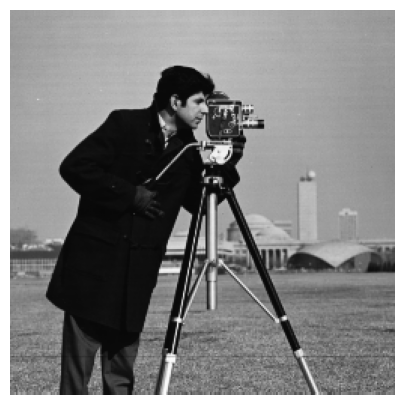

In [4]:
plt.figure(figsize=(5, 5))
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

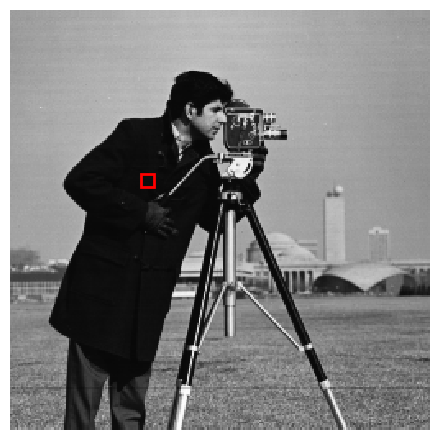

In [5]:
# ------------------------------------------------------------
# Select the same 8×8 block used in the paper
# ------------------------------------------------------------

row = 100
col = 80

block = img[row:row+8, col:col+8]

# ------------------------------------------------------------
# Display image and selected block
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(4.5, 4.5))

ax.imshow(
    img,
    cmap="gray",
    interpolation="nearest",
    vmin=0,
    vmax=255
)

ax.add_patch(
    Rectangle(
        (col - 0.5, row - 0.5),
        8,
        8,
        edgecolor="red",
        linewidth=2,
        facecolor="none"
    )
)

ax.axis("off")

plt.tight_layout()

plt.show()

DS-QSP Experiment (Hadamard)
Block size         : 8 × 8
State dimension    : 64
Amplitude qubits   : 6
Retained coeffs    : 6


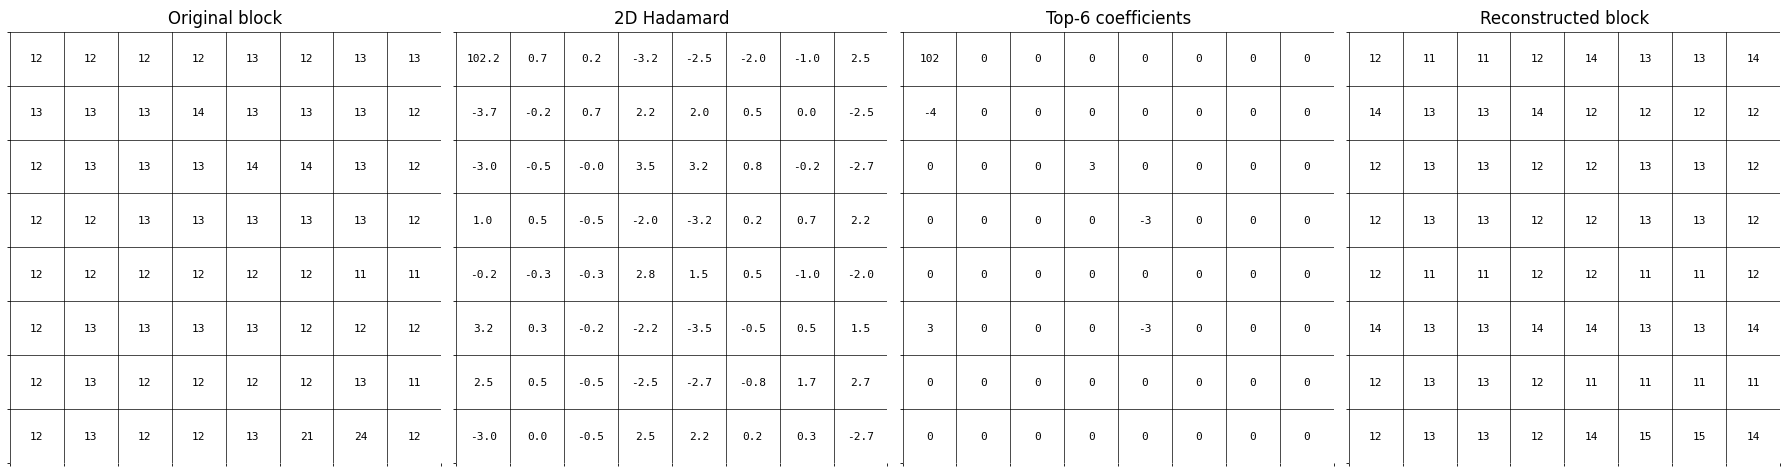

In [15]:
# ============================================================
# DS-QSP experiment using 2D Hadamard Transform
# ============================================================

# ------------------------------------------------------------
# User parameters
# ------------------------------------------------------------

row = 100                  # upper-left row of selected block
col = 80                   # upper-left column of selected block

block_size = 8             # 8, 16, 32, ...
k_keep = 6                 # retained Hadamard coefficients

# ------------------------------------------------------------
# Derived quantities
# ------------------------------------------------------------

dimension = block_size ** 2
nqubits = int(np.log2(dimension))

assert 2 ** nqubits == dimension, \
    "block_size must satisfy block_size^2 = 2^n."

assert 1 <= k_keep <= dimension, \
    "Invalid number of retained coefficients."

print("=" * 45)
print("DS-QSP Experiment (Hadamard)")
print("=" * 45)
print(f"Block size         : {block_size} × {block_size}")
print(f"State dimension    : {dimension}")
print(f"Amplitude qubits   : {nqubits}")
print(f"Retained coeffs    : {k_keep}")
print("=" * 45)

# ------------------------------------------------------------
# Extract block
# ------------------------------------------------------------

block = img[
    row:row + block_size,
    col:col + block_size
]

# ------------------------------------------------------------
# Classical DS-QSP pipeline
# ------------------------------------------------------------

b_had = hadamard_transform_2d(block)

xt = top_k_threshold(
    b_had,
    k_keep
)

x_recons = inverse_hadamard_transform_2d(xt)

# ------------------------------------------------------------
# Plot helper
# ------------------------------------------------------------

def draw_matrix(ax, matrix, decimals=None):

    N = matrix.shape[0]

    ax.imshow(
        np.ones((N, N)),
        cmap="gray",
        interpolation="nearest",
        vmin=0,
        vmax=1
    )

    ax.set_xticks(np.arange(-0.5, N, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, N, 1), minor=True)

    ax.grid(
        which="minor",
        color="black",
        linewidth=0.5
    )

    ax.set_xticks([])
    ax.set_yticks([])

    fontsize = max(3, int(70 / N))

    for i in range(N):
        for j in range(N):

            value = matrix[i, j]

            if decimals is None:
                text = f"{int(np.round(value))}"
            else:
                text = f"{value:.{decimals}f}"

            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=fontsize,
                family="monospace"
            )

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xlim(-0.5, N - 0.5)
    ax.set_ylim(N - 0.5, -0.5)
    ax.set_aspect("equal")

# ------------------------------------------------------------
# Plot classical pipeline
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    4,
    figsize=(18, 4.8)
)

titles = [
    "Original block",
    "2D Hadamard",
    f"Top-{k_keep} coefficients",
    "Reconstructed block"
]

matrices = [
    block,
    b_had,
    np.round(xt),
    np.round(x_recons)
]

decimals = [
    None,
    1,
    None,
    None
]

for ax, title, M, d in zip(
    axes,
    titles,
    matrices,
    decimals
):
    draw_matrix(ax, M, decimals=d)
    ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.show()

In [16]:
def draw_matrix_highlight(ax, matrix, k=None, decimals=1):

    N = matrix.shape[0]

    # Find the k largest coefficients by magnitude
    mask = np.zeros_like(matrix, dtype=bool)

    if k is not None:
        flat = np.abs(matrix).ravel()
        idx = np.argpartition(flat, -k)[-k:]
        mask.ravel()[idx] = True

    # White background
    ax.imshow(
        np.ones((N, N)),
        cmap="gray",
        interpolation="nearest",
        vmin=0,
        vmax=1
    )

    ax.set_xticks(np.arange(-0.5, N, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, N, 1), minor=True)

    ax.grid(which="minor", color="black", linewidth=0.5)

    ax.set_xticks([])
    ax.set_yticks([])

    fontsize = max(3, int(70 / N))

    for i in range(N):
        for j in range(N):

            # Highlight retained coefficients
            if mask[i, j]:
                color = "#FFD54F"      # Gold
            else:
                color = "white"

            ax.add_patch(
                plt.Rectangle(
                    (j - 0.5, i - 0.5),
                    1,
                    1,
                    facecolor=color,
                    edgecolor="none",
                    zorder=0
                )
            )

            value = matrix[i, j]
            text = f"{value:.{decimals}f}"

            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=fontsize,
                family="monospace",
                color="black"
            )

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xlim(-0.5, N - 0.5)
    ax.set_ylim(N - 0.5, -0.5)
    ax.set_aspect("equal")

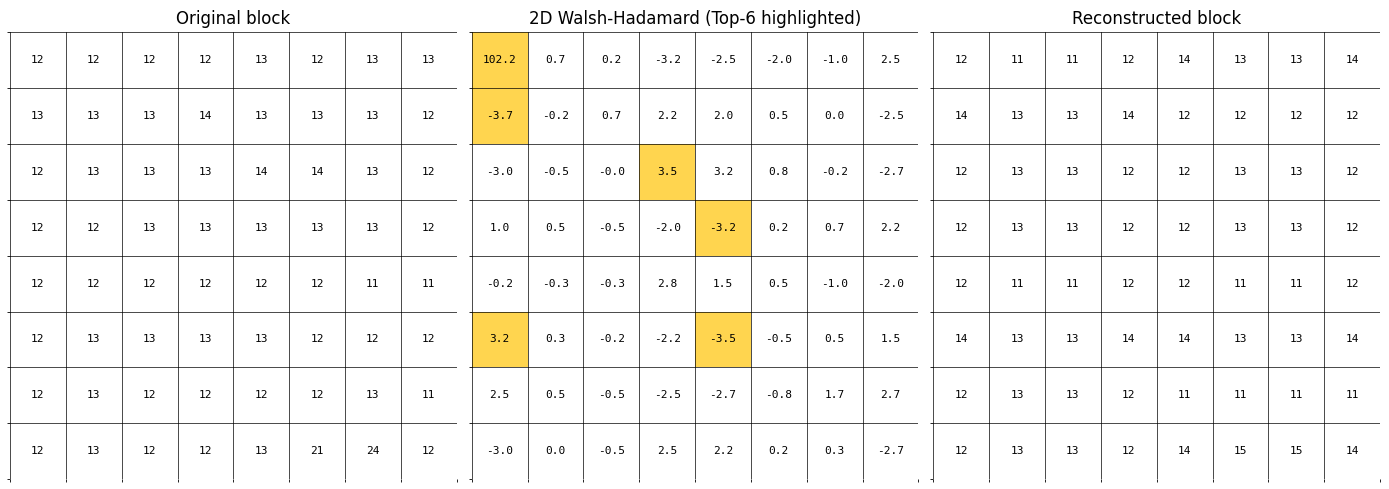

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))

draw_matrix(axes[0], block)
axes[0].set_title("Original block")

draw_matrix_highlight(
    axes[1],
    b_had,
    k=k_keep,
    decimals=1
)
axes[1].set_title(f"2D Walsh-Hadamard (Top-{k_keep} highlighted)")

draw_matrix(axes[2], np.round(x_recons))
axes[2].set_title("Reconstructed block")

plt.tight_layout()
plt.show()


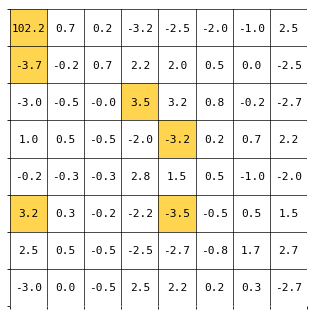

In [18]:
import os

figures_dir = "../figures"   # adjust if needed
os.makedirs(figures_dir, exist_ok=True)



fig, ax = plt.subplots(figsize=(3, 3))

draw_matrix_highlight(
    ax,
    b_had,
    k=k_keep,
    decimals=1
)

plt.tight_layout(pad=0.05)
plt.savefig(
    os.path.join(figures_dir, "walsh_topk_coefficients.pdf"),
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()

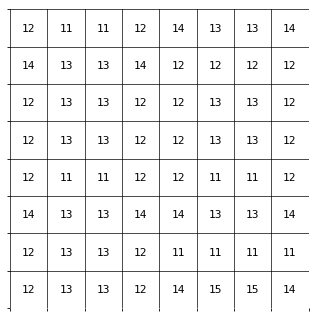

In [19]:
fig, ax = plt.subplots(figsize=(3, 3))

draw_matrix(ax, np.round(x_recons))

plt.tight_layout(pad=0.05)
plt.savefig(
    os.path.join(figures_dir, "walsh_reconstructed_block.pdf"),
    bbox_inches="tight",
    pad_inches=0.02
)


plt.show()

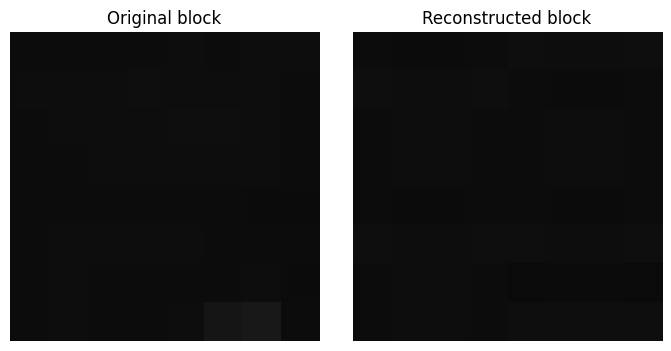

Reconstruction Metrics
PSNR           : 43.9589 dB
SSIM           : 0.969148
Trace distance : 0.12512866


In [20]:
# ============================================================
# Reconstruction quality evaluation
# ============================================================

from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity

# ------------------------------------------------------------
# Classical image metrics
# ------------------------------------------------------------

psnr = peak_signal_noise_ratio(
    block,
    x_recons,
    data_range=255
)

ssim = structural_similarity(
    block,
    x_recons,
    data_range=255
)

# ------------------------------------------------------------
# Quantum-state trace distance
# ------------------------------------------------------------

target_state = block.flatten().astype(float)
target_state /= np.linalg.norm(target_state)

reconstructed_state = x_recons.flatten().astype(float)
reconstructed_state /= np.linalg.norm(reconstructed_state)

td = trace_distance(
    target_state,
    reconstructed_state
)

# ------------------------------------------------------------
# Plot comparison
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(7, 3.5)
)

axes[0].imshow(
    block,
    cmap="gray",
    vmin=0,
    vmax=255,
    interpolation="nearest"
)
axes[0].set_title("Original block")
axes[0].axis("off")

axes[1].imshow(
    x_recons,
    cmap="gray",
    vmin=0,
    vmax=255,
    interpolation="nearest"
)
axes[1].set_title("Reconstructed block")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Display metrics
# ------------------------------------------------------------

print("=" * 45)
print("Reconstruction Metrics")
print("=" * 45)
print(f"PSNR           : {psnr:.4f} dB")
print(f"SSIM           : {ssim:.6f}")
print(f"Trace distance : {td:.8f}")
print("=" * 45)

## Qibo Implementation 

In [21]:
from qibo import Circuit, gates
from qibo.models.encodings import sparse_encoder
from qibo.ui import plot_circuit

In [22]:
# ------------------------------------------------------------
# Normalize states
# ------------------------------------------------------------

target_state = block.flatten().astype(float)
target_state /= np.linalg.norm(target_state)

compressed_state = xt.flatten().astype(float)
x_norm = compressed_state/np.linalg.norm(compressed_state)

Circuit depth = 29
Total number of gates = 51
Number of qubits = 6
Most common gates:
cx: 20
x: 16
ry: 9
h: 6
None


(<Axes: >, <Figure size 360x360 with 1 Axes>)

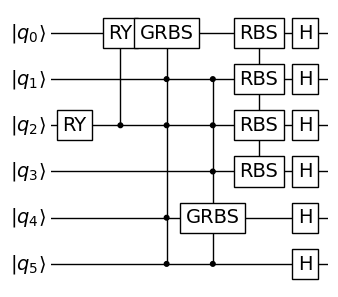

In [23]:
# Sparse transform-domain coefficient vector
vec = x_norm

# Indices of nonzero coefficients
nz = np.flatnonzero(vec)

# Total number of qubits required
# for amplitude encoding
nqubits = int(np.log2(len(vec)))

# Construct sparse basis-state representation
# as (bitstring, amplitude) pairs
y = [
    (format(i, f"0{nqubits}b"), vec[i])
    for i in nz
]

# Prepare sparse quantum state using
# the Farias SQSP method
qc = sparse_encoder(
    y,
    method="farias"
)


for i in range(6):
    qc.add(gates.H(i))

# Display decomposed circuit statistics
# for quantum resource analysis
print(qc.decompose().decompose().decompose().summary())
plot_circuit(qc)

In [34]:
final_state = np.real(qc().state())

td = trace_distance(final_state, target_state)

print(td)

0.10951929825267252


In [35]:
prepared_state = np.real(final_state)

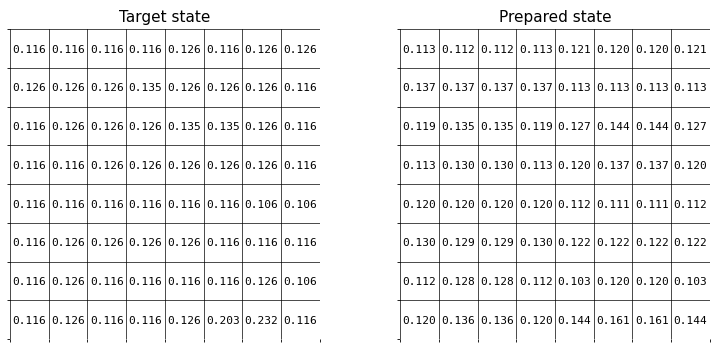

In [36]:
# ============================================================
# Target and prepared quantum states
# ============================================================

target_matrix = target_state.reshape(block_size, block_size)
prepared_matrix = prepared_state.reshape(block_size, block_size)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(8, 3.6)
)

titles = [
    "Target state",
    "Prepared state"
]

for ax, title, M in zip(
    axes,
    titles,
    [target_matrix, prepared_matrix]
):

    draw_matrix(
        ax,
        M,
        decimals=3
    )

    ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.show()

In [37]:
# ============================================================
# Whole-image Hadamard transform experiment
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity,
)

# ------------------------------------------------------------
# Check image size
# ------------------------------------------------------------

N = img.shape[0]

assert img.shape[0] == img.shape[1], \
    "Image must be square."

assert (N & (N - 1)) == 0, \
    "Image dimension must be a power of two."

print(f"Image size : {N} x {N}")

# ------------------------------------------------------------
# Forward transform
# ------------------------------------------------------------

coeffs = hadamard_transform_2d(img.astype(float))

# ------------------------------------------------------------
# Different retained coefficients
# ------------------------------------------------------------

k_values = [
    128,
    256,
    512,
    1024,
    2048,
    4096,
    8192,
    16384,
    32768,
]

print("="*75)
print(f"{'k':>8} {'Retained %':>12} {'PSNR':>12} {'SSIM':>12}")
print("="*75)

for k in k_values:

    coeffs_sparse = top_k_threshold(coeffs, k)

    recon = inverse_hadamard_transform_2d(coeffs_sparse)

    psnr = peak_signal_noise_ratio(
        img,
        recon,
        data_range=255,
    )

    ssim = structural_similarity(
        img,
        recon,
        data_range=255,
    )

    percent = 100 * k / coeffs.size

    print(
        f"{k:8d}"
        f"{percent:12.3f}"
        f"{psnr:12.3f}"
        f"{ssim:12.5f}"
    )

print("="*75)

Image size : 256 x 256
       k   Retained %         PSNR         SSIM
     128       0.195      17.920     0.36039
     256       0.391      18.734     0.37517
     512       0.781      19.697     0.39036
    1024       1.562      20.823     0.42534
    2048       3.125      22.204     0.49194
    4096       6.250      23.903     0.56288
    8192      12.500      26.178     0.64909
   16384      25.000      29.636     0.75725
   32768      50.000      36.250     0.90691


In [38]:
from PIL import Image
import io
import numpy as np
from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity,
)

# ============================================================
# JPEG baseline
# ============================================================

quality_values = [
    5,10,15,20,30,40,50,60,70,80,90,95
]

print("="*75)
print(f"{'Quality':>8} {'Size (KB)':>12} {'PSNR':>12} {'SSIM':>12}")
print("="*75)

for quality in quality_values:

    # ---------------------------------------------
    # Encode to JPEG (memory only)
    # ---------------------------------------------

    buffer = io.BytesIO()

    Image.fromarray(img.astype(np.uint8)).save(
        buffer,
        format="JPEG",
        quality=quality
    )

    size_kb = len(buffer.getvalue()) / 1024

    # ---------------------------------------------
    # Decode
    # ---------------------------------------------

    buffer.seek(0)

    recon = np.array(Image.open(buffer)).astype(float)

    # ---------------------------------------------
    # Metrics
    # ---------------------------------------------

    psnr = peak_signal_noise_ratio(
        img,
        recon,
        data_range=255,
    )

    ssim = structural_similarity(
        img,
        recon,
        data_range=255,
    )

    print(
        f"{quality:8d}"
        f"{size_kb:12.2f}"
        f"{psnr:12.3f}"
        f"{ssim:12.5f}"
    )

print("="*75)

 Quality    Size (KB)         PSNR         SSIM
       5        1.90      24.446     0.72625
      10        2.68      26.471     0.79511
      15        3.38      27.709     0.83588
      20        4.00      28.591     0.85917
      30        5.14      29.938     0.88365
      40        6.05      30.895     0.89950
      50        7.00      31.743     0.91298
      60        7.99      32.629     0.92514
      70        9.51      33.853     0.93794
      80       11.96      35.799     0.95327
      90       17.55      39.914     0.97290
      95       25.17      44.137     0.98494
